# NYC Taxi Fare Prediction

## Data Understanding

This notebook examines the raw NYC taxi trip data before cleaning.

The objective is to:
- Understand the structure of the raw dataset
- Inspect feature and target distributions
- Identify issues that require cleaning

The prediction target is `fare_amount`. The remaining variables describe trip time, location and passenger count.

## Load Development Sample

The required libraries are imported before loading a sample of the raw data.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

The complete training dataset contains more than 55 million trips. A 100,000-row sample is used for efficient exploration.

In [2]:
DATA_PATH = "../data/raw/train.csv"

df = pd.read_csv(
    DATA_PATH,
    nrows=100_000,
    parse_dates=["pickup_datetime"]
)

df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1


## Dataset Overview

The sample size and column structure are inspected first.

In [3]:
df.shape

(100000, 8)

The development sample contains 100,000 trips and 8 variables. `fare_amount` is the target, while the remaining variables provide potential predictive features.

### Data Types

Data types are checked to confirm that each variable is interpreted correctly.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                100000 non-null  str                
 1   fare_amount        100000 non-null  float64            
 2   pickup_datetime    100000 non-null  datetime64[us, UTC]
 3   pickup_longitude   100000 non-null  float64            
 4   pickup_latitude    100000 non-null  float64            
 5   dropoff_longitude  100000 non-null  float64            
 6   dropoff_latitude   100000 non-null  float64            
 7   passenger_count    100000 non-null  int64              
dtypes: datetime64[us, UTC](1), float64(5), int64(1), str(1)
memory usage: 6.1 MB


All columns contain non-null values, and `pickup_datetime` has been parsed correctly for later time-based feature engineering.

### Numerical Summary

Summary statistics are used to identify unexpected values and ranges.

In [5]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,11.354652,-72.494682,39.914481,-72.490967,39.919053,1.673820
std,9.716777,10.693934,6.225686,10.471386,6.213427,1.300171
min,-44.900000,-736.550000,-74.007670,-84.654241,-74.006377,0.000000
25%,6.000000,-73.992041,40.734996,-73.991215,40.734182,1.000000
50%,8.500000,-73.981789,40.752765,-73.980000,40.753243,1.000000
75%,12.500000,-73.966982,40.767258,-73.963433,40.768166,2.000000
max,200.000000,40.787575,401.083332,40.851027,404.616667,6.000000


### Initial Findings

The numerical ranges reveal three potential data quality issues:

- `fare_amount` includes negative values.
- Some coordinates exceed valid geographic ranges.
- `passenger_count` includes zero-passenger trips.

## Missing Value Analysis

Missing values are checked before applying cleaning rules.

In [6]:
df.isnull().sum()

key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

No missing values were found in the development sample. The same check should be repeated when the pipeline is applied to the full dataset.

## Duplicate Record Analysis

Fully duplicated rows are checked because repeated observations may bias model training.

In [7]:
df.duplicated().sum()

np.int64(0)

No fully duplicated rows were found. The trip identifier `key` can be validated again on the complete dataset.

## Fare Amount Exploration

The target distribution is inspected for invalid values and extreme observations that may affect regression models.

In [8]:
df["fare_amount"].describe()

count    100000.000000
mean         11.354652
std           9.716777
min         -44.900000
25%           6.000000
50%           8.500000
75%          12.500000
max         200.000000
Name: fare_amount, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

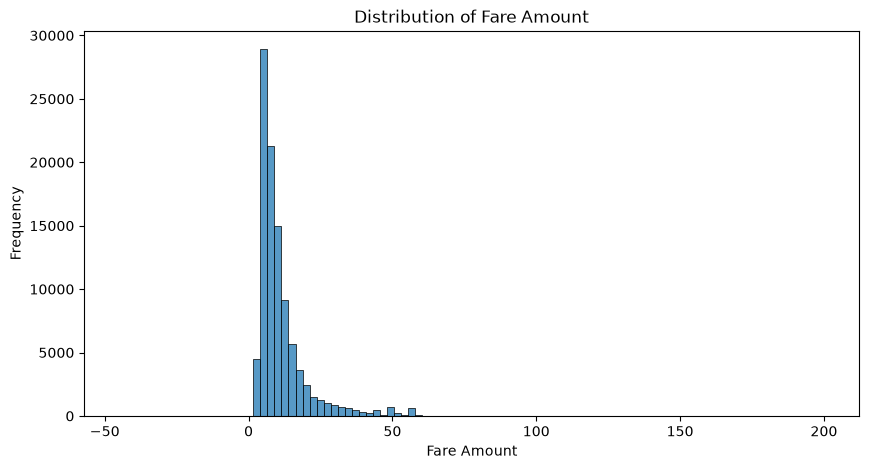

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["fare_amount"],
    bins=100
)

plt.title("Distribution of Fare Amount")
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")

plt.show

## Geographic Coordinate Analysis

Pickup longitude and latitude ranges are inspected for impossible geographic values and locations outside the expected NYC area.

In [10]:
print("Longtiude range:")
print(
    df["pickup_longitude"].max(),
    df["pickup_longitude"].min()
)

print("\nLatitude range:")
print(
    df["pickup_latitude"].max(),
    df["pickup_latitude"].min()
)

Longtiude range:
40.787575 -736.55

Latitude range:
401.083332 -74.00767


## Passenger Count Analysis

Passenger-count frequencies are inspected to identify invalid or unusual trip occupancy.

In [11]:
df["passenger_count"].value_counts().sort_index()


passenger_count
0      366
1    69619
2    14561
3     4289
4     2091
5     7034
6     2040
Name: count, dtype: int64

## Data Understanding Summary

The development sample contains no missing or fully duplicated rows. However, it includes:

- Negative fare amounts
- Invalid geographic coordinates
- Zero-passenger trips

These findings define the cleaning rules applied in the next notebook.